<a href="https://colab.research.google.com/github/sankajithdjinasena/Data_Visualization_Practical/blob/main/Data_Visualization_2026_06_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Usable Functions**

In [137]:
import numpy as np

def remove_outlier(df):
    num_df = df.select_dtypes(include=[np.number])

    q1 = num_df.quantile(0.25)
    q3 = num_df.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = ~((num_df < lower_bound) | (num_df > upper_bound)).any(axis=1)

    return df[mask]

# **Practical**

## Load the dataset and required Libraries

In [138]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [139]:
df = sns.load_dataset("taxis")
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [141]:
df.isna().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [142]:
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [143]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')

<Figure size 1500x800 with 0 Axes>

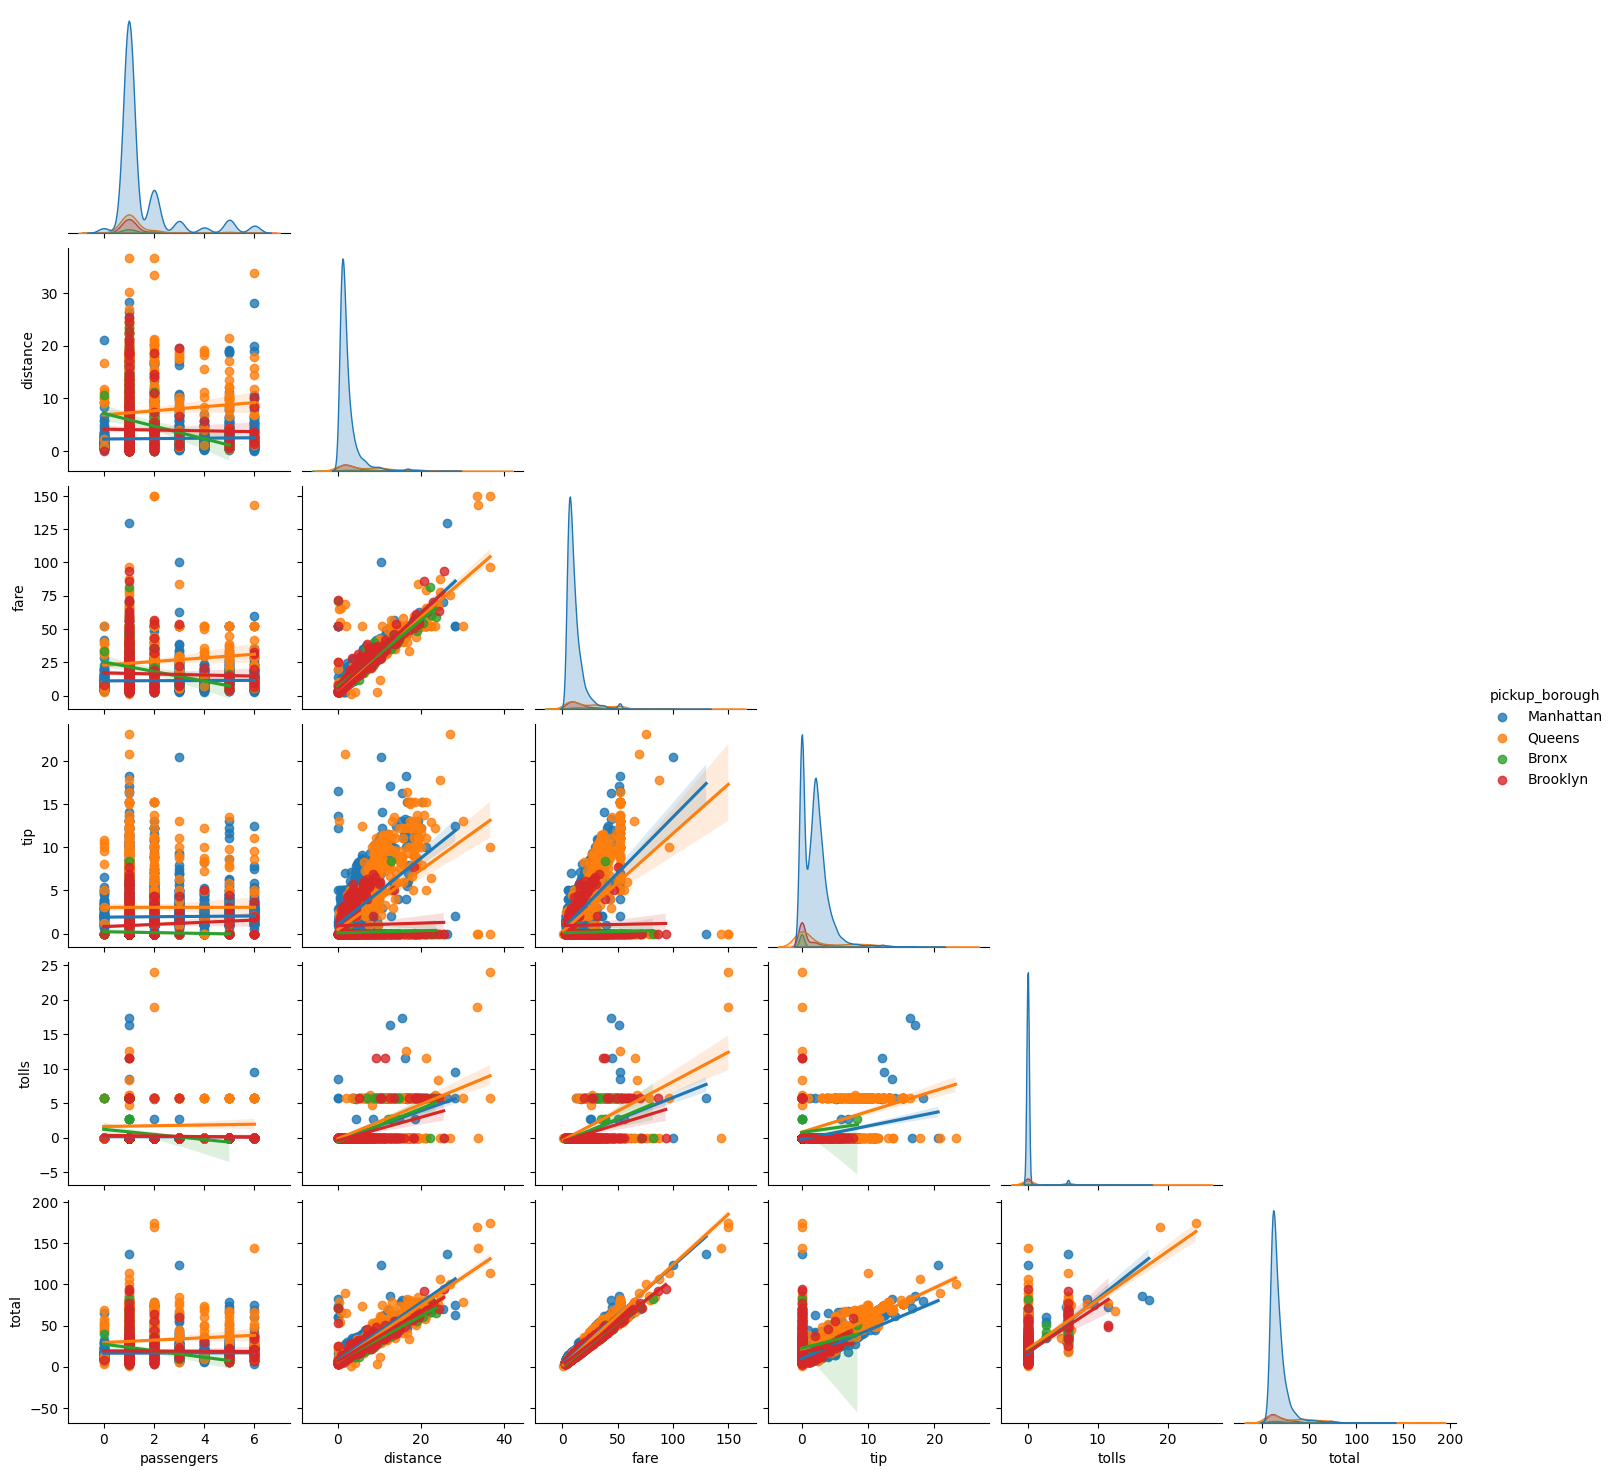

In [144]:
plt.figure(figsize=(15, 8))
sns.pairplot(data=df, hue="pickup_borough", corner=True, diag_kind="kde", kind="reg")
plt.show()

## **Task 1**

/tmp/ipykernel_12642/2532132757.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pickup_borough', y='distance',palette="Set3")


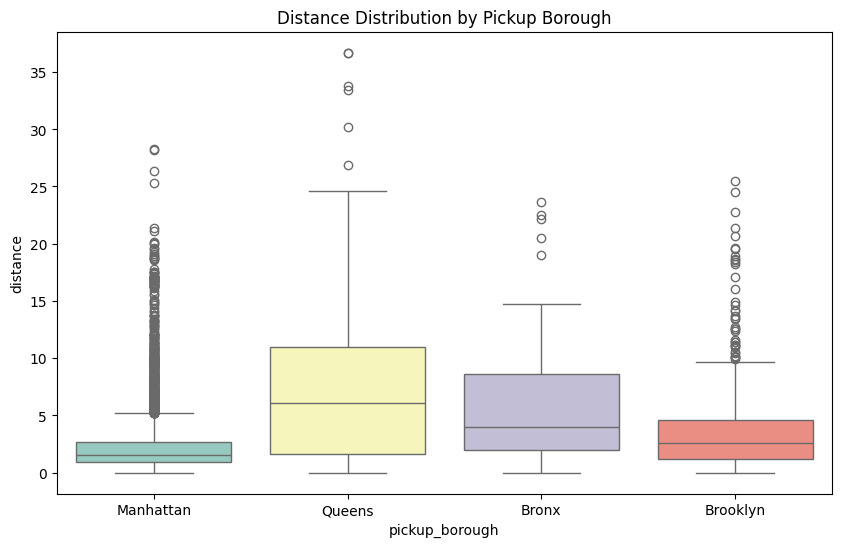

In [145]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='pickup_borough', y='distance',palette="Set3")
plt.title('Distance Distribution by Pickup Borough')
plt.show()

## **Task 2**

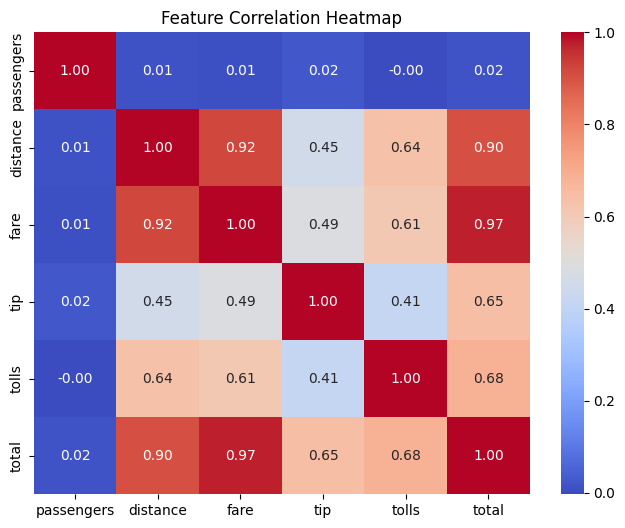

In [146]:
df_taxis = df.select_dtypes(include=[np.number])

plt.figure(figsize=(8, 6))
correlation_matrix = df_taxis.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

## **Task 3**

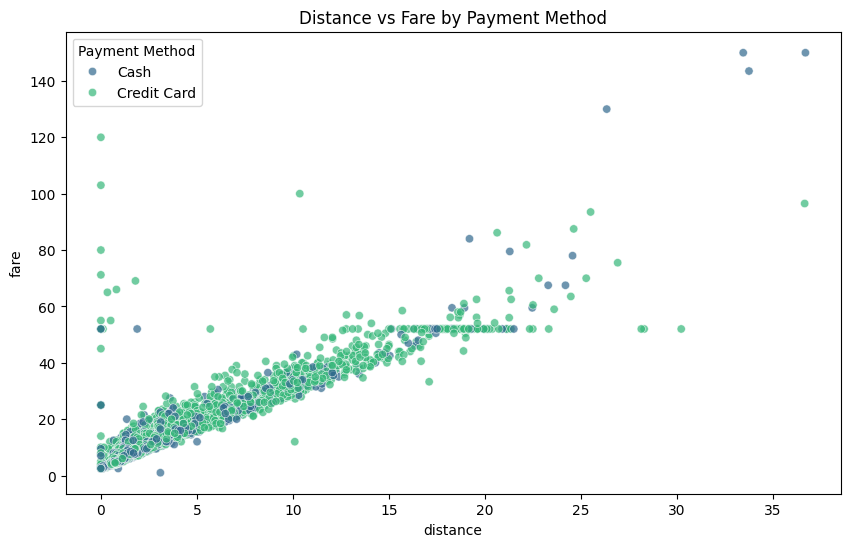

In [147]:
df['payment_encoded'] = df['payment'].map({'credit card': 1, 'cash': 0})

plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df,
    x='distance',
    y='fare',
    hue='payment_encoded',
    palette='viridis',
    alpha=0.7,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Cash', 'Credit Card'], title='Payment Method')

plt.title('Distance vs Fare by Payment Method')
plt.show()

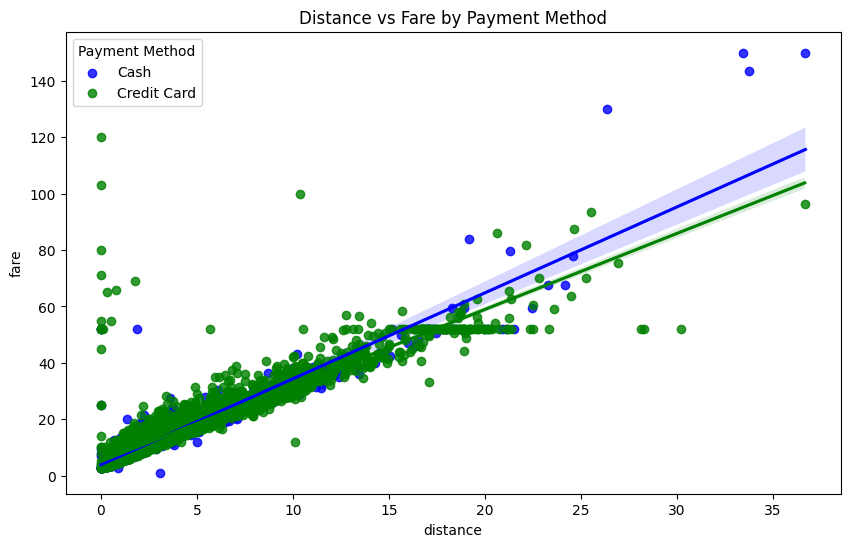

In [148]:
plt.figure(figsize=(10, 6))

for payment, color in zip(['cash', 'credit card'], ['blue', 'green']):
    subset = df[df['payment'] == payment]

    sns.regplot(
        data=subset,
        x='distance',
        y='fare',
        scatter=True,
        label=payment.title(),
        color=color
    )

plt.legend(title='Payment Method')
plt.title('Distance vs Fare by Payment Method')
plt.show()

## **Task 4**

In [149]:
df_messy = sns.load_dataset('taxis')
df_messy.loc[0:20, 'tip'] = 'System Error'
df_messy.loc[21:50, 'tip'] = 'NaN'
df_messy.loc[51:100, 'tip'] = np.nan

df_messy['tip'] = pd.to_numeric(df_messy['tip'], errors='coerce')

print("Cleaned Data type of 'tip':", df_messy['tip'].dtype)

Cleaned Data type of 'tip': float64


/tmp/ipykernel_12642/653423325.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'System Error' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_messy.loc[0:20, 'tip'] = 'System Error'


# **Data Preprocessing**

* Filling Missing values





In [150]:
df.isna().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [151]:
df["pickup_zone"].value_counts()

,count
pickup_zone,
Midtown Center,230
Upper East Side South,211
Penn Station/Madison Sq West,210
Clinton East,208
Midtown East,198
...,...
Ozone Park,1
Glendale,1
Woodlawn/Wakefield,1


In [152]:
df["pickup_zone"] = df["pickup_zone"].fillna(df["pickup_zone"].mode()[0])

In [153]:
df["payment"].value_counts()

,count
payment,
credit card,4577
cash,1812


In [154]:
df["payment"] = df["payment"].fillna(df["payment"].mode()[0])

In [155]:
df["dropoff_zone"].value_counts()

,count
dropoff_zone,
Upper East Side North,245
Murray Hill,220
Midtown Center,215
Upper East Side South,177
Midtown East,176
...,...
Queensboro Hill,1
Homecrest,1
Madison,1


In [156]:
df["dropoff_zone"] = df["dropoff_zone"].fillna(df["dropoff_zone"].mode()[0])

In [157]:
df["pickup_borough"].value_counts()

,count
pickup_borough,
Manhattan,5268
Queens,657
Brooklyn,383
Bronx,99


In [158]:
df["pickup_borough"] = df["pickup_borough"].fillna(df["pickup_borough"].mode()[0])

In [159]:
df["dropoff_borough"].value_counts()

,count
dropoff_borough,
Manhattan,5206
Queens,542
Brooklyn,501
Bronx,137
Staten Island,2


In [160]:
df["dropoff_borough"] = df["dropoff_borough"].fillna(df["dropoff_borough"].mode()[0])

In [161]:
df = sns.load_dataset("taxis")
cleaned_df = remove_outlier(df)

In [162]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5150 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           5150 non-null   datetime64[ns]
 1   dropoff          5150 non-null   datetime64[ns]
 2   passengers       5150 non-null   int64         
 3   distance         5150 non-null   float64       
 4   fare             5150 non-null   float64       
 5   tip              5150 non-null   float64       
 6   tolls            5150 non-null   float64       
 7   total            5150 non-null   float64       
 8   color            5150 non-null   object        
 9   payment          5112 non-null   object        
 10  pickup_zone      5132 non-null   object        
 11  dropoff_zone     5126 non-null   object        
 12  pickup_borough   5132 non-null   object        
 13  dropoff_borough  5126 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(1), o

/tmp/ipykernel_12642/1934147.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cleaned_df, x='pickup_borough', y='distance',palette="Set3")


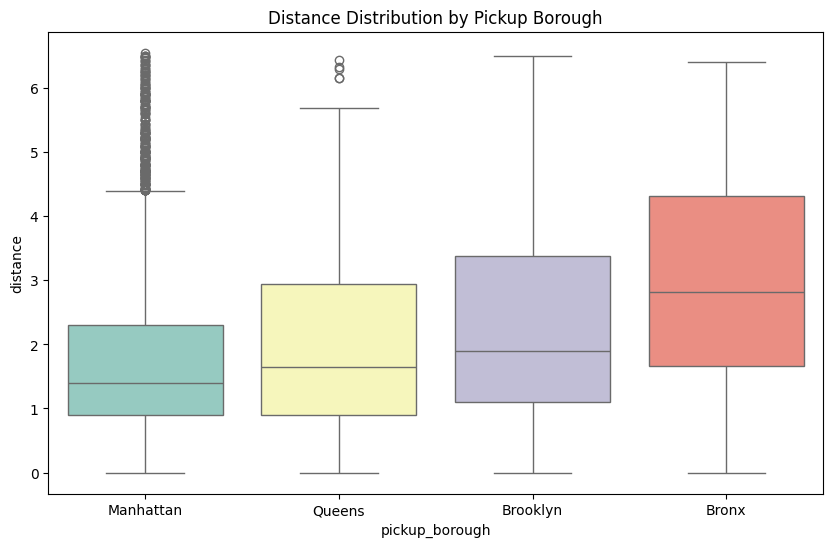

In [163]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=cleaned_df, x='pickup_borough', y='distance',palette="Set3")
plt.title('Distance Distribution by Pickup Borough')
plt.show()

In [164]:
cleaned_df = remove_outlier(cleaned_df)

/tmp/ipykernel_12642/1934147.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cleaned_df, x='pickup_borough', y='distance',palette="Set3")


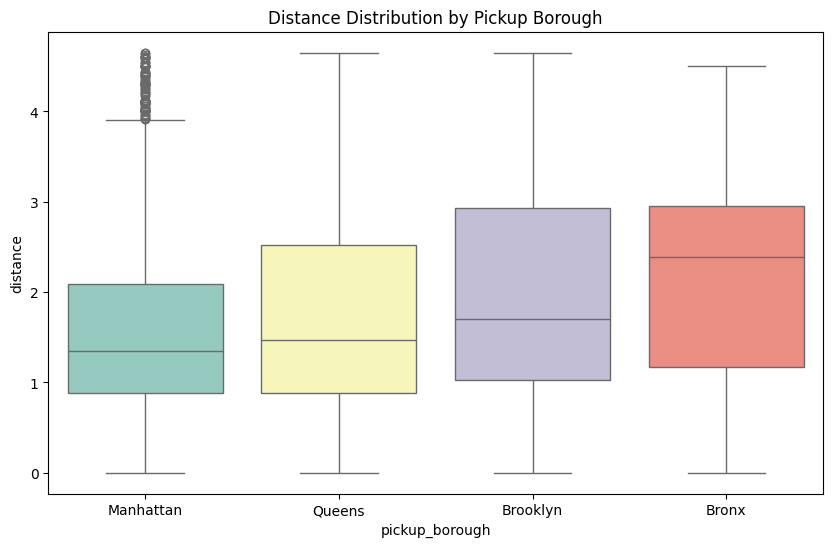

In [165]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=cleaned_df, x='pickup_borough', y='distance',palette="Set3")
plt.title('Distance Distribution by Pickup Borough')
plt.show()

In [170]:
cleaned_df["pickup_zone"] = cleaned_df["pickup_zone"].fillna(cleaned_df["pickup_zone"].mode()[0])
cleaned_df["payment"] = cleaned_df["payment"].fillna(cleaned_df["payment"].mode()[0])
cleaned_df["dropoff_zone"] = cleaned_df["dropoff_zone"].fillna(cleaned_df["dropoff_zone"].mode()[0])
cleaned_df["pickup_borough"] = cleaned_df["pickup_borough"].fillna(cleaned_df["pickup_borough"].mode()[0])
cleaned_df["dropoff_borough"] = cleaned_df["dropoff_borough"].fillna(cleaned_df["dropoff_borough"].mode()[0])

In [171]:
data = cleaned_df.copy()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3839 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           3839 non-null   datetime64[ns]
 1   dropoff          3839 non-null   datetime64[ns]
 2   passengers       3839 non-null   int64         
 3   distance         3839 non-null   float64       
 4   fare             3839 non-null   float64       
 5   tip              3839 non-null   float64       
 6   tolls            3839 non-null   float64       
 7   total            3839 non-null   float64       
 8   color            3839 non-null   object        
 9   payment          3839 non-null   object        
 10  pickup_zone      3839 non-null   object        
 11  dropoff_zone     3839 non-null   object        
 12  pickup_borough   3839 non-null   object        
 13  dropoff_borough  3839 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(1), o

## **Task 1 - After Preprocess**

/tmp/ipykernel_12642/1934147.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cleaned_df, x='pickup_borough', y='distance',palette="Set3")


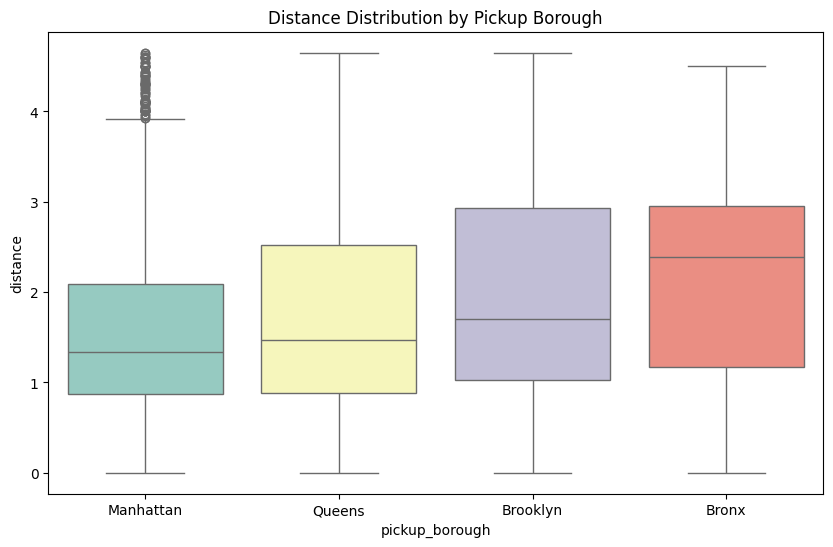

In [174]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='pickup_borough', y='distance',palette="Set3")
plt.title('Distance Distribution by Pickup Borough')
plt.show()

## **Task 2 - After Preprocess**

In [184]:
data.column

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough', 'payment_encoded'],
      dtype='object')

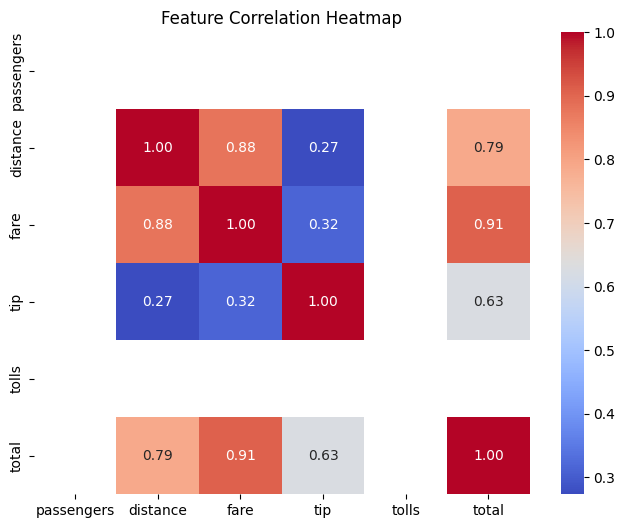

In [175]:
data_taxis = data.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
correlation_matrix = data_taxis.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

## **Task 3 - After Preprocess**

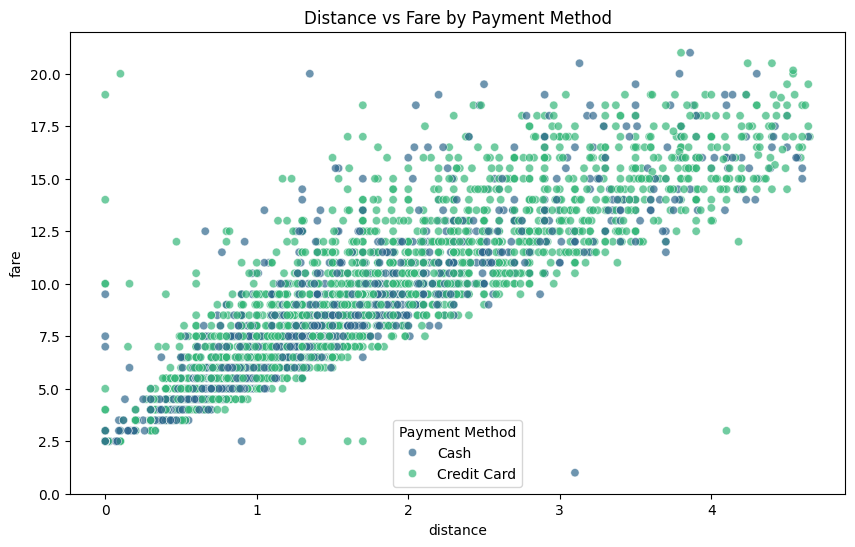

In [176]:
data['payment_encoded'] = data['payment'].map({'credit card': 1, 'cash': 0})

plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=data,
    x='distance',
    y='fare',
    hue='payment_encoded',
    palette='viridis',
    alpha=0.7,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Cash', 'Credit Card'], title='Payment Method')

plt.title('Distance vs Fare by Payment Method')
plt.show()

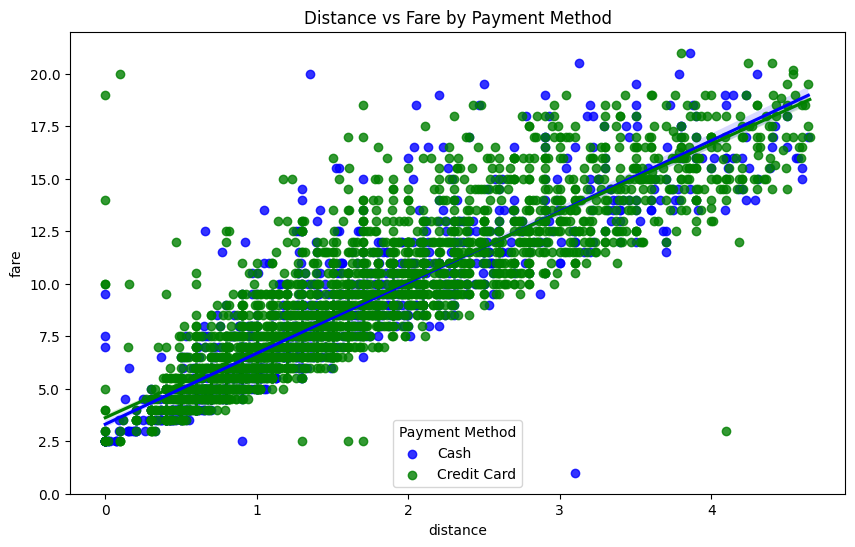

In [183]:
plt.figure(figsize=(10, 6))

for payment, color in zip(['cash', 'credit card'], ['blue', 'green']):
    subset = data[data['payment'] == payment]

    sns.regplot(
        data=subset,
        x='distance',
        y='fare',
        scatter=True,
        label=payment.title(),
        color=color
    )

plt.legend(title='Payment Method')
plt.title('Distance vs Fare by Payment Method')
plt.show()